In [1]:
# ============================================================
# CELDA 1 — Imports y carga de datos
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

# Rutas
BASE      = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED = os.path.join(BASE, 'data', 'processed')
REPORTS   = os.path.join(BASE, 'reports')
MODELS    = os.path.join(BASE, 'src', 'models')
os.makedirs(MODELS, exist_ok=True)

# Carga
df = pd.read_csv(os.path.join(PROCESSED, 'listings_clean.csv'), low_memory=False)

print(f"Dataset cargado: {df.shape[0]:,} filas | {df.shape[1]} columnas")
print(f"XGBoost version: {xgb.__version__}")

Dataset cargado: 69,142 filas | 33 columnas
XGBoost version: 3.2.0


In [2]:
# ============================================================
# CELDA 2 — Preparación de features para el modelo
# ============================================================

# Features seleccionadas para predecir ocupación
FEATURES = [
    'ciudad',
    'neighbourhood_cleansed',
    'room_type',
    'accommodates',
    'bedrooms',
    'bathrooms',
    'beds',
    'price',
    'minimum_nights',
    'availability_365',
    'number_of_reviews',
    'number_of_reviews_ltm',
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_location',
    'review_scores_value',
    'reviews_per_month',
    'host_is_superhost',
    'host_listings_count',
    'instant_bookable',
]

TARGET = 'ocupacion'

# Eliminamos filas con nulos en features o target
df_model = df[FEATURES + [TARGET]].dropna().copy()

print(f"Dataset para modelado: {len(df_model):,} filas")
print(f"Features: {len(FEATURES)}")

# Codificamos variables categóricas
le_ciudad  = LabelEncoder()
le_barrio  = LabelEncoder()
le_room    = LabelEncoder()

df_model['ciudad_enc']  = le_ciudad.fit_transform(df_model['ciudad'])
df_model['barrio_enc']  = le_barrio.fit_transform(df_model['neighbourhood_cl

SyntaxError: unterminated string literal (detected at line 43) (731523062.py, line 43)

In [3]:
# ============================================================
# CELDA 2 — Preparación de features para el modelo
# ============================================================

FEATURES = [
    'ciudad', 'neighbourhood_cleansed', 'room_type',
    'accommodates', 'bedrooms', 'bathrooms', 'beds',
    'price', 'minimum_nights', 'availability_365',
    'number_of_reviews', 'number_of_reviews_ltm',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
    'reviews_per_month', 'host_is_superhost',
    'host_listings_count', 'instant_bookable',
]

TARGET = 'ocupacion'

df_model = df[FEATURES + [TARGET]].dropna().copy()
print(f"Dataset para modelado: {len(df_model):,} filas")

le_ciudad = LabelEncoder()
le_barrio = LabelEncoder()
le_room   = LabelEncoder()

df_model['ciudad_enc'] = le_ciudad.fit_transform(df_model['ciudad'])
df_model['barrio_enc'] = le_barrio.fit_transform(df_model['neighbourhood_cleansed'])
df_model['room_enc']   = le_room.fit_transform(df_model['room_type'])

FEATURES_NUM = [
    'ciudad_enc', 'barrio_enc', 'room_enc',
    'accommodates', 'bedrooms', 'bathrooms', 'beds',
    'price', 'minimum_nights', 'availability_365',
    'number_of_reviews', 'number_of_reviews_ltm',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
    'reviews_per_month', 'host_is_superhost',
    'host_listings_count', 'instant_bookable',
]

X = df_model[FEATURES_NUM]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Ocupación media train: {y_train.mean():.3f}")
print(f"Ocupación media test:  {y_test.mean():.3f}")

Dataset para modelado: 53,078 filas
Train: 42,462 | Test: 10,616
Ocupación media train: 0.333
Ocupación media test:  0.333


In [4]:
# ============================================================
# CELDA 3 — Entrenamiento XGBoost
# ============================================================

modelo_xgb = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=20,
    eval_metric='mae'
)

modelo_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("\n✅ Modelo entrenado correctamente")
print(f"Mejor iteración: {modelo_xgb.best_iteration}")

[0]	validation_0-mae:0.22314
[50]	validation_0-mae:0.02575
[100]	validation_0-mae:0.00697
[150]	validation_0-mae:0.00474
[200]	validation_0-mae:0.00399
[250]	validation_0-mae:0.00357
[300]	validation_0-mae:0.00331
[350]	validation_0-mae:0.00313
[400]	validation_0-mae:0.00299
[450]	validation_0-mae:0.00288
[499]	validation_0-mae:0.00279

✅ Modelo entrenado correctamente
Mejor iteración: 499


=== MÉTRICAS DE EVALUACIÓN — XGBoost Ocupación ===
MAE  (Error Absoluto Medio):      0.0028  (0.28 puntos porcentuales)
RMSE (Raíz Error Cuadrático):     0.0048
R²   (Varianza explicada):        0.9997  (100.0%)


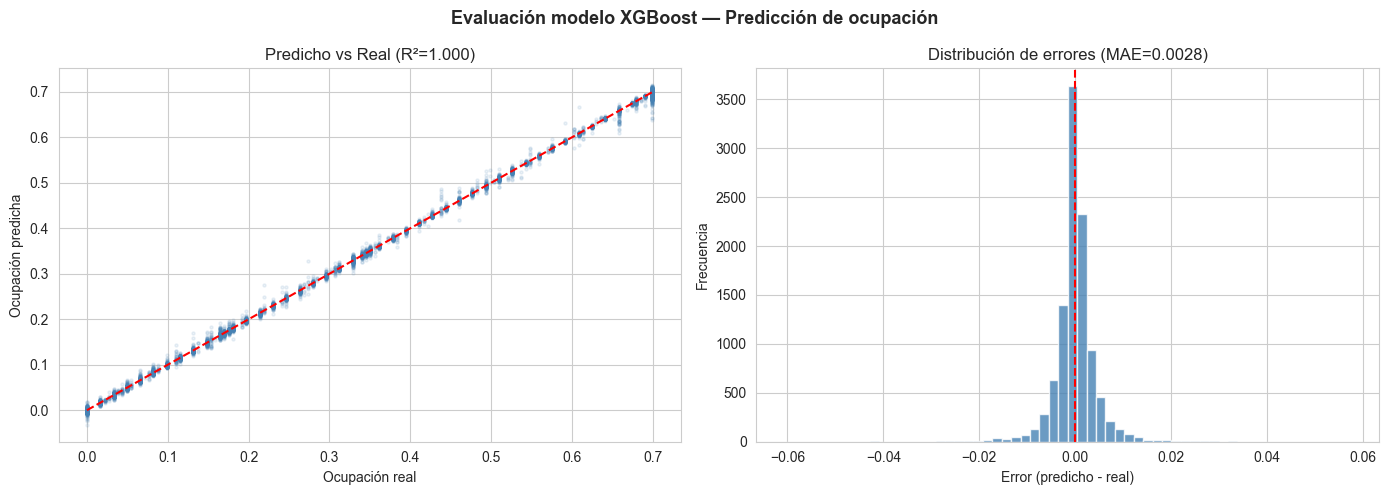

In [6]:
# ============================================================
# CELDA 4 — Evaluación del modelo
# ============================================================

y_pred = modelo_xgb.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=== MÉTRICAS DE EVALUACIÓN — XGBoost Ocupación ===")
print(f"MAE  (Error Absoluto Medio):      {mae:.4f}  ({mae*100:.2f} puntos porcentuales)")
print(f"RMSE (Raíz Error Cuadrático):     {rmse:.4f}")
print(f"R²   (Varianza explicada):        {r2:.4f}  ({r2*100:.1f}%)")

# Gráfico predicho vs real
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter predicho vs real
axes[0].scatter(y_test, y_pred, alpha=0.1, s=5, color='steelblue')
axes[0].plot([0, 0.7], [0, 0.7], 'r--', linewidth=1.5)
axes[0].set_xlabel('Ocupación real')
axes[0].set_ylabel('Ocupación predicha')
axes[0].set_title(f'Predicho vs Real (R²={r2:.3f})')

# Distribución de errores
errores = y_pred - y_test
axes[1].hist(errores, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Error (predicho - real)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title(f'Distribución de errores (MAE={mae:.4f})')

plt.suptitle('Evaluación modelo XGBoost — Predicción de ocupación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'xgboost_evaluacion.png'), dpi=150, bbox_inches='tight')
plt.show()

=== IMPORTANCIA DE VARIABLES ===
                  feature  importancia
    number_of_reviews_ltm     0.597059
           minimum_nights     0.153919
        number_of_reviews     0.100834
        reviews_per_month     0.058588
        host_is_superhost     0.023097
               ciudad_enc     0.019457
         instant_bookable     0.017220
                 room_enc     0.013398
                    price     0.008253
     review_scores_rating     0.002401
         availability_365     0.001533
      host_listings_count     0.001279
               barrio_enc     0.000803
      review_scores_value     0.000784
   review_scores_location     0.000440
                 bedrooms     0.000430
             accommodates     0.000167
                     beds     0.000125
review_scores_cleanliness     0.000119
                bathrooms     0.000092


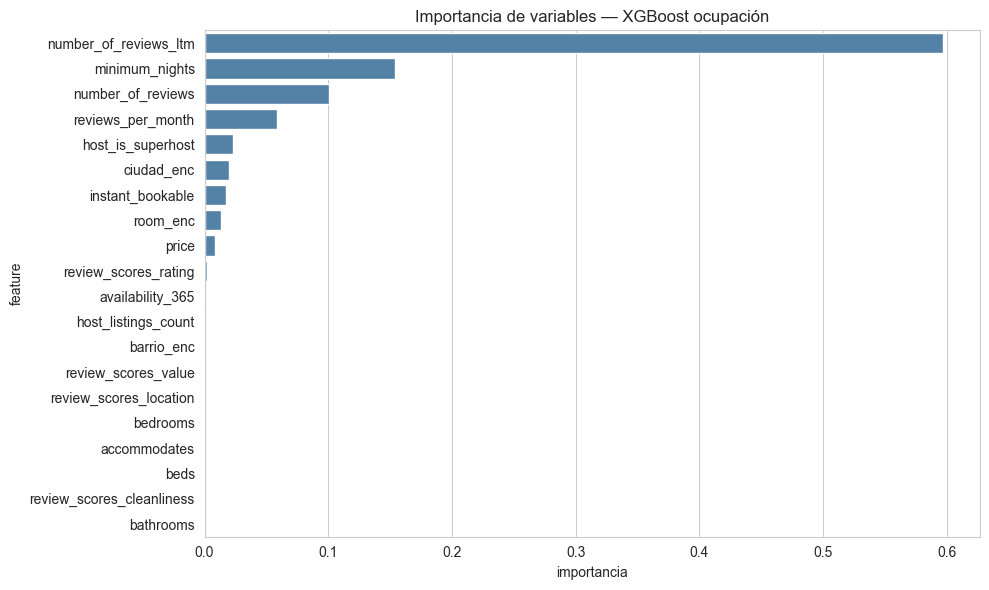

In [7]:
# ============================================================
# CELDA 5 — Diagnóstico de data leakage
# ============================================================

importancias = pd.DataFrame({
    'feature': FEATURES_NUM,
    'importancia': modelo_xgb.feature_importances_
}).sort_values('importancia', ascending=False)

print("=== IMPORTANCIA DE VARIABLES ===")
print(importancias.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=importancias, x='importancia', y='feature', color='steelblue')
plt.title('Importancia de variables — XGBoost ocupación')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'xgboost_importancia.png'), dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ============================================================
# CELDA 6 — Reentrenamiento sin variables con leakage
# ============================================================

# Features limpias: solo características del inmueble y del host
FEATURES_LIMPIAS = [
    'ciudad_enc', 'barrio_enc', 'room_enc',
    'accommodates', 'bedrooms', 'bathrooms', 'beds',
    'price', 'minimum_nights', 'availability_365',
    'host_is_superhost', 'host_listings_count',
    'instant_bookable',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
]

X2 = df_model[FEATURES_LIMPIAS]
y2 = df_model[TARGET]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

modelo_xgb2 = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=20,
    eval_metric='mae'
)

modelo_xgb2.fit(
    X2_train, y2_train,
    eval_set=[(X2_test, y2_test)],
    verbose=50
)

y2_pred = modelo_xgb2.predict(X2_test)

mae2  = mean_absolute_error(y2_test, y2_pred)
rmse2 = np.sqrt(mean_squared_error(y2_test, y2_pred))
r2_2  = r2_score(y2_test, y2_pred)

print("\n=== MÉTRICAS SIN LEAKAGE ===")
print(f"MAE:  {mae2:.4f}  ({mae2*100:.2f} puntos porcentuales)")
print(f"RMSE: {rmse2:.4f}")
print(f"R²:   {r2_2:.4f}  ({r2_2*100:.1f}%)")

[0]	validation_0-mae:0.23044
[50]	validation_0-mae:0.15840
[100]	validation_0-mae:0.14731
[150]	validation_0-mae:0.14263
[200]	validation_0-mae:0.13960
[250]	validation_0-mae:0.13706
[300]	validation_0-mae:0.13516
[350]	validation_0-mae:0.13344
[400]	validation_0-mae:0.13204
[450]	validation_0-mae:0.13087
[499]	validation_0-mae:0.12979

=== MÉTRICAS SIN LEAKAGE ===
MAE:  0.1298  (12.98 puntos porcentuales)
RMSE: 0.1662
R²:   0.5970  (59.7%)


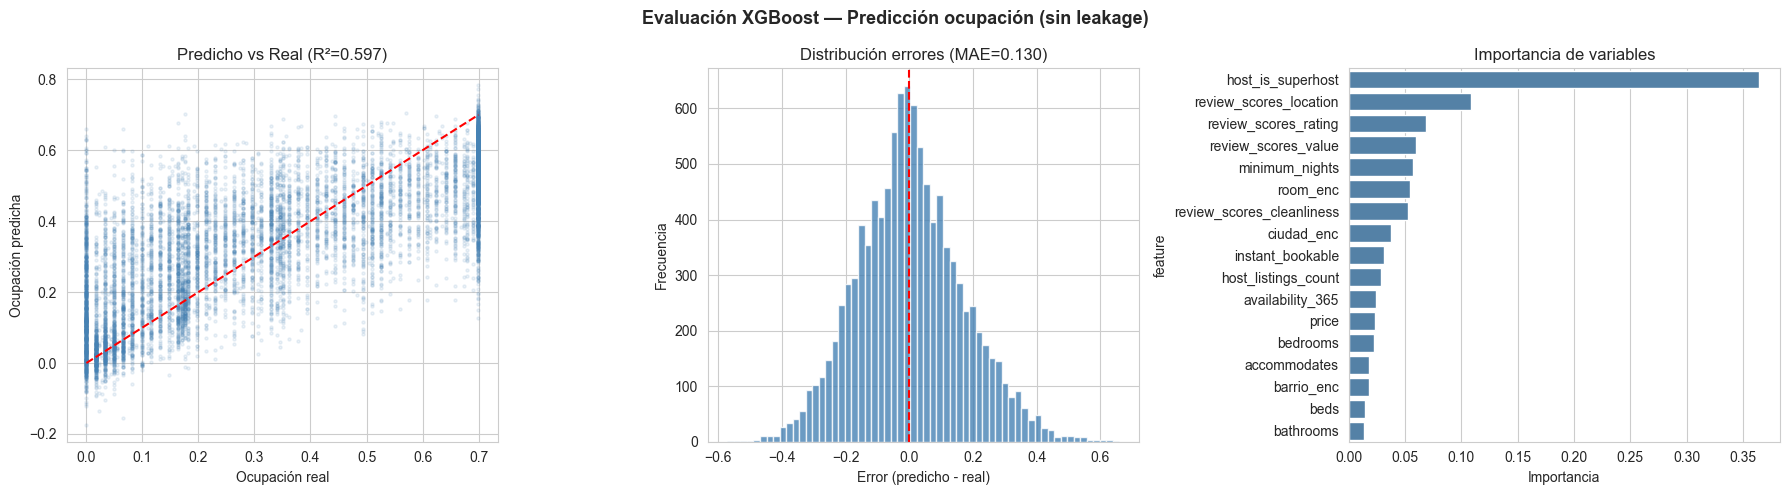


=== IMPORTANCIA DE VARIABLES ===
                  feature  importancia
        host_is_superhost     0.364586
   review_scores_location     0.108500
     review_scores_rating     0.068936
      review_scores_value     0.059770
           minimum_nights     0.056936
                 room_enc     0.054395
review_scores_cleanliness     0.053127
               ciudad_enc     0.037240
         instant_bookable     0.031731
      host_listings_count     0.029136
         availability_365     0.024366
                    price     0.023369
                 bedrooms     0.022581
             accommodates     0.018323
               barrio_enc     0.018033
                     beds     0.014894
                bathrooms     0.014079


In [9]:
# ============================================================
# CELDA 7 — Evaluación visual modelo limpio
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter predicho vs real
axes[0].scatter(y2_test, y2_pred, alpha=0.1, s=5, color='steelblue')
axes[0].plot([0, 0.7], [0, 0.7], 'r--', linewidth=1.5)
axes[0].set_xlabel('Ocupación real')
axes[0].set_ylabel('Ocupación predicha')
axes[0].set_title(f'Predicho vs Real (R²={r2_2:.3f})')

# Distribución errores
errores2 = y2_pred - y2_test
axes[1].hist(errores2, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Error (predicho - real)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title(f'Distribución errores (MAE={mae2:.3f})')

# Importancia de variables
importancias2 = pd.DataFrame({
    'feature': FEATURES_LIMPIAS,
    'importancia': modelo_xgb2.feature_importances_
}).sort_values('importancia', ascending=False)

sns.barplot(data=importancias2, x='importancia', y='feature', 
            color='steelblue', ax=axes[2])
axes[2].set_title('Importancia de variables')
axes[2].set_xlabel('Importancia')

plt.suptitle('Evaluación XGBoost — Predicción ocupación (sin leakage)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'xgboost_evaluacion_limpia.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n=== IMPORTANCIA DE VARIABLES ===")
print(importancias2.to_string(index=False))

In [10]:
# ============================================================
# CELDA 8 — Guardado del modelo y encoders
# ============================================================
import pickle

# Guardamos modelo
ruta_modelo = os.path.join(MODELS, 'xgboost_ocupacion.pkl')
with open(ruta_modelo, 'wb') as f:
    pickle.dump(modelo_xgb2, f)

# Guardamos encoders
ruta_encoders = os.path.join(MODELS, 'encoders_ocupacion.pkl')
encoders = {
    'le_ciudad': le_ciudad,
    'le_barrio': le_barrio,
    'le_room':   le_room,
    'features':  FEATURES_LIMPIAS
}
with open(ruta_encoders, 'wb') as f:
    pickle.dump(encoders, f)

# Guardamos métricas
metricas = {
    'mae':  mae2,
    'rmse': rmse2,
    'r2':   r2_2,
    'n_train': len(X2_train),
    'n_test':  len(X2_test)
}
ruta_metricas = os.path.join(MODELS, 'metricas_xgboost_ocupacion.pkl')
with open(ruta_metricas, 'wb') as f:
    pickle.dump(metricas, f)

print("✅ Modelo guardado:", ruta_modelo)
print("✅ Encoders guardados:", ruta_encoders)
print("✅ Métricas guardadas:", ruta_metricas)

# Verificamos tamaños
for ruta in [ruta_modelo, ruta_encoders, ruta_metricas]:
    tam = os.path.getsize(ruta) / (1024)
    print(f"   {os.path.basename(ruta)}: {tam:.1f} KB")

✅ Modelo guardado: /Users/ivannavarrosuero/tfm_vut/src/models/xgboost_ocupacion.pkl
✅ Encoders guardados: /Users/ivannavarrosuero/tfm_vut/src/models/encoders_ocupacion.pkl
✅ Métricas guardadas: /Users/ivannavarrosuero/tfm_vut/src/models/metricas_xgboost_ocupacion.pkl
   xgboost_ocupacion.pkl: 2220.3 KB
   encoders_ocupacion.pkl: 3.7 KB
   metricas_xgboost_ocupacion.pkl: 0.2 KB
